In [1]:
import random
import numpy as np
import matplotlib.pyplot as plt

# Задача 1

In [2]:
def christmas_tree(x: int):
    if not (x >= 2 and x <= 100):
        raise ValueError("Width must be between 2 and 100")

    rows = [x * ' ' + '*' + x * ' ']

    for i in range(1, x + 1):
        rows.append((x-i) * ' ' + i * '/' + '|' + i * '\\')

    rows.append(x * ' ' + '|' + x * ' ')

    print('\n'.join(rows))


In [3]:
christmas_tree(5)

     *     
    /|\
   //|\\
  ///|\\\
 ////|\\\\
/////|\\\\\
     |     


# Задача 2

In [4]:
def monte_carlo_ln(n: int):
    if not (n > 0):
        raise ValueError("n must be greater than 0")

    hits = 0

    for _ in range(n):
        x = random.random() + 1
        y = random.random()

        hits += int(y < 1/x)

    return hits / n

In [5]:
monte_carlo_ln(10000000)

0.6932389

In [6]:
%timeit monte_carlo_ln(10000000)

1.04 s ± 28.3 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


# Задача 3

In [7]:
def np_monte_carlo_ln(n: int):
    if not (n > 0):
        raise ValueError("n must be greater than 0")

    x = np.random.random(n) + 1
    y = np.random.random(n)

    hits = (y < 1/x).sum()

    return hits / n

In [8]:
np_monte_carlo_ln(10000000)

np.float64(0.6930978)

In [9]:
%timeit np_monte_carlo_ln(10000000)

143 ms ± 3.23 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)


# Задача 4

In [10]:
def generate_monte_carlo_np_sample(n_samples: int = 100, n_points: int = 1000):
    if not (n_samples > 0 and n_points > 0):
        raise ValueError("Number of samples and number of points must be greater than 0")
    
    sample = np.zeros((n_samples,))

    for i in range(n_samples):
        sample[i] = np_monte_carlo_ln(n_points)

    return sample

def calculate_sample_statistics(sample: np.ndarray):
    print(f'Min:            {sample.min()}')
    print(f'Max:            {sample.max()}')
    print(f'Mean:           {sample.mean()}')
    print(f'Median:         {np.median(sample)}')
    print(f'Std:            {sample.std()}')
    print(f'First quantile: {np.quantile(sample,0.25)}')
    print(f'Third quantile: {np.quantile(sample,0.75)}')

def generate_and_get_statistics():
    sample = generate_monte_carlo_np_sample(10000, 10000)

    calculate_sample_statistics(sample)

In [11]:
generate_and_get_statistics()

Min:            0.6749
Max:            0.7106
Mean:           0.6932038399999999
Median:         0.6932
Std:            0.004658908161189701
First quantile: 0.6901
Third quantile: 0.6964


# Задача 5

In [12]:
def run_mc_blackjack_experiment(N: int):
    # Prepare deck and corresponding points
    card_scores = [ i for i in range(2, 10) ] + 4*[10] + [11]
    card_scores *= 4

    experiment_scores = np.zeros(N)
    for i in range(N):
        score = np.random.choice(card_scores, size=2, replace=False).sum()
        if score > 21:
            score = 12

        experiment_scores[i] = score

    return experiment_scores    

In [13]:
scores = run_mc_blackjack_experiment(100000)

print('---------------- Experiment -----------------')
print(f'Mean: {scores.mean()}')
print(f'Std:  {scores.std()}')

---------------- Experiment -----------------
Mean: 14.57365
Std:  4.057621923922928


In [14]:
def blackjack_score(): 
    scores = [i for i in range(2, 10)] + 4*[10] + [11]
    scores = np.repeat(scores, 4)

    score_combinations = np.repeat(scores, 52).reshape(-1,52)
    score_combinations += scores

    # Alternative:
    # score_combinations = np.add.outer(scores, scores)

    upper_triangular_m = np.triu(score_combinations, k=1) # k=1: without diagonal

    flat_scores = upper_triangular_m.flatten()
    flat_scores = flat_scores[flat_scores != 0]
    flat_scores[flat_scores > 21] = 12

    return np.mean(flat_scores), np.std(flat_scores), np.var(flat_scores)

In [15]:
mean, std, var = blackjack_score()

print(f'Mean: {mean:.2f}')
print(f'Std:  {std:.2f}')
print(f'Var:  {var:.2f}')

Mean: 14.57
Std:  4.06
Var:  16.49


# Задача 6

In [16]:
def mc_ln2_estimate(n: int, plot=False):
    if not (n > 0):
        raise ValueError("n must be greater than 0")

    x = np.random.random(n) + 1
    y = np.random.random(n)

    hits = (y < 1/x).sum()

    if plot:
        grid = np.linspace(1, 2, 100)
        f = 1/grid

        plt.plot(grid, f, color='darkgreen', linewidth=3)
        plt.scatter(x, y, c=(y > 1/x), s=8, cmap='bwr', alpha=0.5)


    return hits / n

np.float64(0.695)

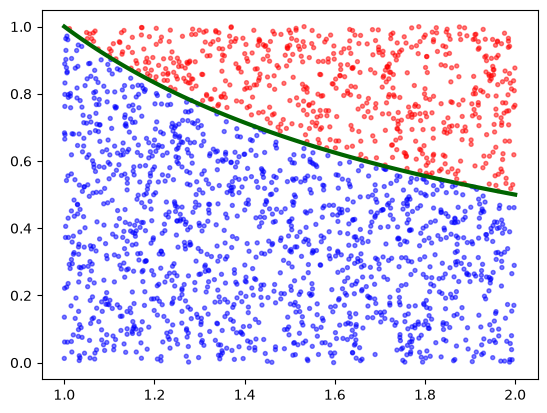

In [17]:
mc_ln2_estimate(2000, plot=True)